# Tire Pressure vs Lateral Force

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as stats

df = pd.read_csv("B2356raw9.dat", sep='\s+', header=1, skiprows=[2])
df = df.apply(pd.to_numeric, errors='coerce')
df.head()

,ET,V,N,SA,IA,RL,RE,P,FX,FY,...,MX,MZ,NFX,NFY,RST,TSTI,TSTC,TSTO,AmbTmp,SR
0,0.00,0.02,0.01,0.004,-0.012,19.32,697.32,82.41,3.37,-56.08,...,-2.65,1.50,-0.0030,0.0502,32.39,37.48,39.43,41.51,26.39,-0.9723
1,0.01,0.03,0.01,-0.004,-0.016,19.32,968.73,82.46,2.40,-54.67,...,-2.52,1.13,-0.0021,0.0489,32.40,37.46,39.45,41.48,26.37,-0.9801
2,0.02,0.03,0.01,-0.004,-0.003,19.32,968.73,82.51,1.86,-54.73,...,-2.51,0.90,-0.0017,0.0490,32.40,37.43,39.41,41.50,26.38,-0.9801
3,0.03,0.01,-0.06,-0.007,0.001,19.31,-65.53,82.41,1.85,-53.36,...,-2.15,0.92,-0.0017,0.0478,32.39,37.44,39.40,41.50,26.39,-1.2948
4,0.04,0.04,0.01,0.012,-0.002,19.31,1240.13,82.26,0.04,-51.96,...,-2.07,0.50,-0.0000,0.0466,32.39,37.41,39.40,41.46,26.38,-0.9844


In [2]:
# Given parameters: normal load, slip angle
targetFZ = -1112
toleranceFZ = 50
targetSA = 6.0
toleranceSA = 0.2

In [3]:
# Filter dataframe for rows where load and slip angle match targets
points = df[
    (df['FZ'].between(targetFZ - toleranceFZ, targetFZ + toleranceFZ)) &
    (df['SA'].between(targetSA - toleranceSA, targetSA + toleranceSA))
]

# Group by the target pressure and average the lateral force
points['P_target'] = (points['P'] * 0.145038).round(0)
summary = points.groupby('P_target')['FY'].mean().reset_index()

/tmp/ipykernel_719/515135301.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  points['P_target'] = (points['P'] * 0.145038).round(0)


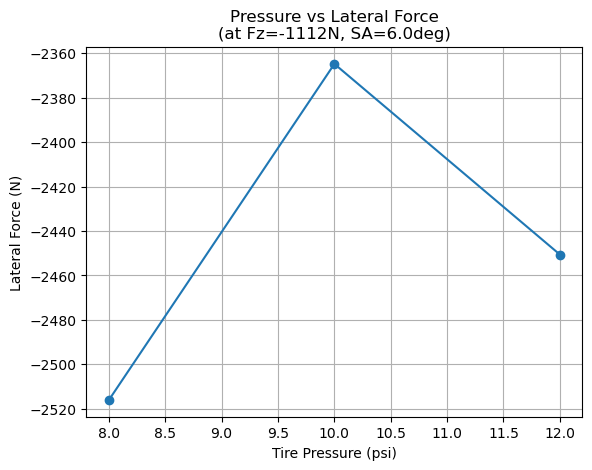

In [4]:
# Plot
plt.plot(summary['P_target'], summary['FY'], marker='o', linestyle='-')
plt.title(f'Pressure vs Lateral Force\n(at Fz={targetFZ}N, SA={targetSA}deg)')
plt.xlabel('Tire Pressure (psi)')
plt.ylabel('Lateral Force (N)')
plt.grid(True)
plt.show()

# Investigation of Energy Transfer Into Tires
## Formulas:
Power dissipation formula
P_d = -(FX * V + FY * V * sin(SA) + M_z * omega_z)
- Longitudinal slip power: FX * Sliding Velocity
- Lateral slip power: FY * V * sin(SA)
- Steering power: M_z * omega_z
- M_z is the aligning torque
- omega_z is the angular velocity ~ delta SA / delta time

In [5]:
# Changing units
df['V_ms'] = df['V']/3.6 # changes V from kph to mps
df['SA_rad'] = np.radians(df['SA']) # changes SA from deg to rad

# Calculating parts for the power dissipation formula
# lateral slip power:
df['Power_Lat'] = df['FY']*df['V_ms']*np.sin(df['SA_rad'])
# average temperature:
df['Temp_avg'] = (df['TSTI'] + df['TSTC'] + df['TSTO']) / 3

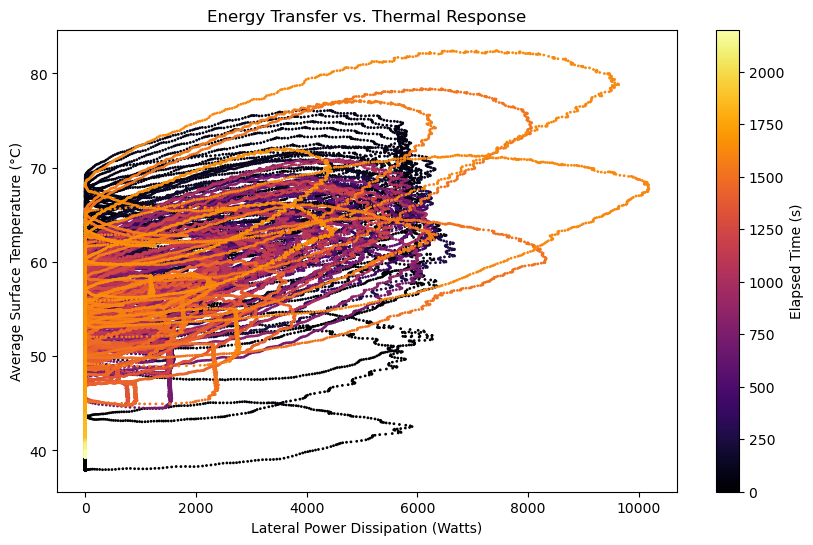

In [6]:
# Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Power_Lat'].abs(), df['Temp_avg'], c=df['ET'], cmap='inferno', s=1)
plt.xlabel('Lateral Power Dissipation (Watts)')
plt.ylabel('Average Surface Temperature (°C)')
plt.title('Energy Transfer vs. Thermal Response')
plt.colorbar(label='Elapsed Time (s)')
plt.show()

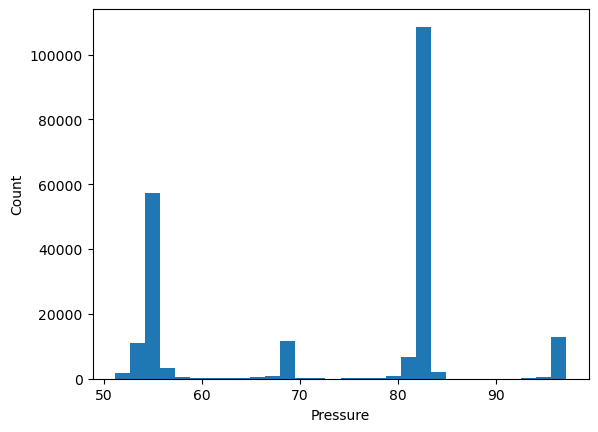

In [7]:
plt.hist(df["P"], bins=30)
plt.xlabel("Pressure")
plt.ylabel("Count")
plt.show()

In [25]:
bins = [7, 9, 11, 13, 15]
labels = ["8 psi","10 psi", "12 psi", "14 psi"]
df_clean = df[(df["FZ"] <- 200) & (abs(df["SA"]) < 15) & (abs(df["SR"]))]
df_clean["P_psi"] = df_clean["P"]/6.89476
df_clean["P_psi"].describe()

/tmp/ipykernel_719/3039168252.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["P_psi"] = df_clean["P"]/6.89476


count    219216.000000
mean         10.607959
std           2.030183
min           7.411425
25%           7.998828
50%          11.938052
75%          11.996067
max          14.094762
Name: P_psi, dtype: float64

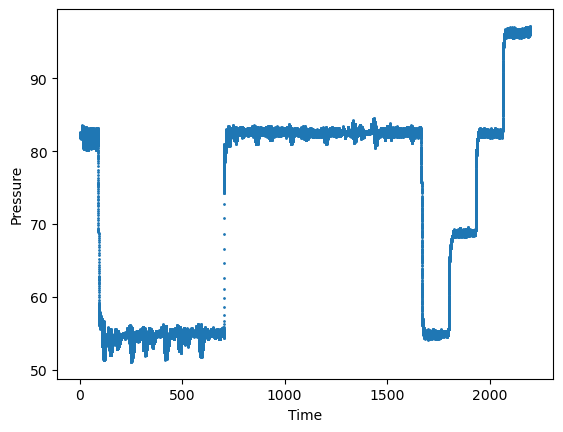

In [26]:
plt.scatter(df_clean["ET"], df_clean["P"], s=1)
plt.xlabel("Time")
plt.ylabel("Pressure")
plt.show()

In [27]:
df_clean["P_bin"] = pd.cut(df_clean["P_psi"], bins=bins, labels=labels)
df_clean["P_bin"].value_counts()

/tmp/ipykernel_719/1355784179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["P_bin"] = pd.cut(df_clean["P_psi"], bins=bins, labels=labels)


P_bin
12 psi    118203
8 psi      74093
10 psi     13492
14 psi     13428
Name: count, dtype: int64

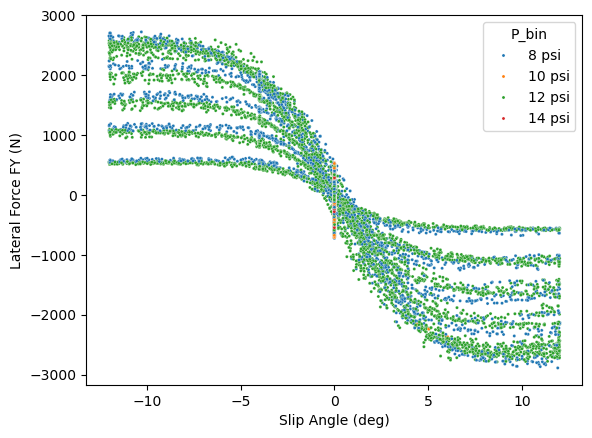

In [28]:
sns.scatterplot(
    data=df_clean.sample(20000),
    x="SA",
    y="FY",
    hue="P_bin",
    s=5
)
plt.xlabel("Slip Angle (deg)")
plt.ylabel("Lateral Force FY (N)")
plt.show()

In [29]:
peak_fy = df_clean.groupby("P_bin")["FY"].max()
scale = peak_fy / peak_fy.loc["12 psi"]
print(scale)

P_bin
8 psi     1.027148
10 psi    0.204115
12 psi    1.000000
14 psi    0.177936
Name: FY, dtype: float64


/tmp/ipykernel_719/3659239555.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peak_fy = df_clean.groupby("P_bin")["FY"].max()


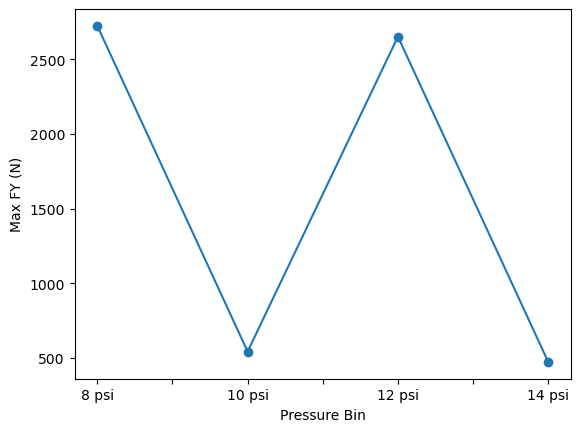

In [30]:
peak_fy.plot(marker='o')
plt.ylabel("Max FY (N)")
plt.xlabel("Pressure Bin")
plt.show()

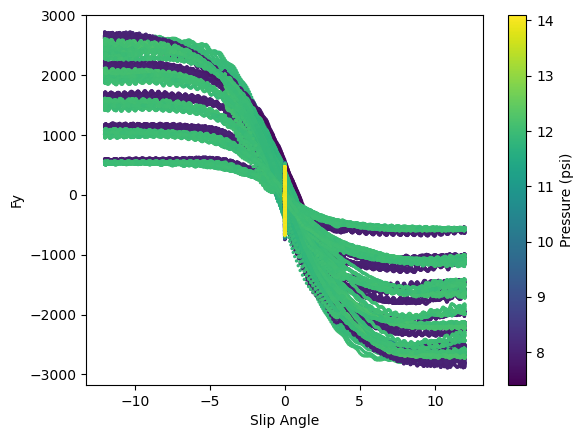

In [31]:
plt.scatter(
    df_clean["SA"],
    df_clean["FY"],
    c=df_clean["P_psi"],
    s=2,
    cmap="viridis"
)

plt.colorbar(label="Pressure (psi)")
plt.xlabel("Slip Angle")
plt.ylabel("Fy")
plt.show()

In [32]:
df_slice = df_clean[
    (df_clean["FZ"] < -600) &
    (df_clean["FZ"] > -750) &
    (abs(df_clean["IA"]) < 0.5)
]
df_slice["FZ_lb"] = -df_slice["FZ"] * 0.224809
df_slice["FY_lb"] = df_slice["FY"] * 0.224809
sa_bins = np.linspace(-15, 15, 60)

df_slice["SA_bin"] = pd.cut(df_slice["SA"], bins=sa_bins)
curve_data = df_slice.groupby(["P_bin","SA_bin"])["FY_lb"].mean().reset_index()
curve_data["SA_center"] = curve_data["SA_bin"].apply(lambda x: x.mid)

/tmp/ipykernel_719/2035983604.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice["FZ_lb"] = -df_slice["FZ"] * 0.224809
/tmp/ipykernel_719/2035983604.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice["FY_lb"] = df_slice["FY"] * 0.224809
/tmp/ipykernel_719/2035983604.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/panda

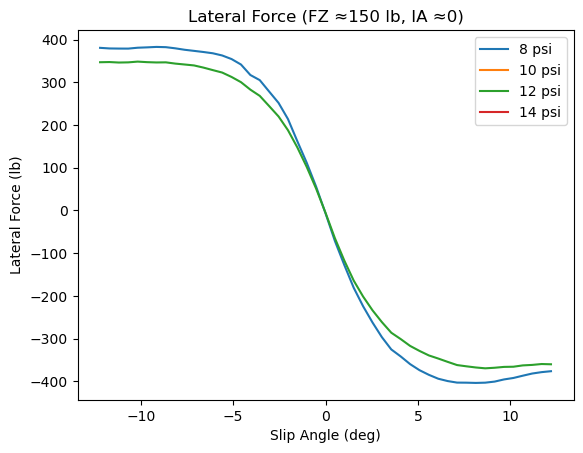

In [33]:
for p in curve_data["P_bin"].unique():
    
    subset = curve_data[curve_data["P_bin"] == p]
    
    plt.plot(
        subset["SA_center"],
        subset["FY_lb"],
        label=p
    )

plt.xlabel("Slip Angle (deg)")
plt.ylabel("Lateral Force (lb)")
plt.title("Lateral Force (FZ ≈150 lb, IA ≈0)")
plt.legend()
plt.show()

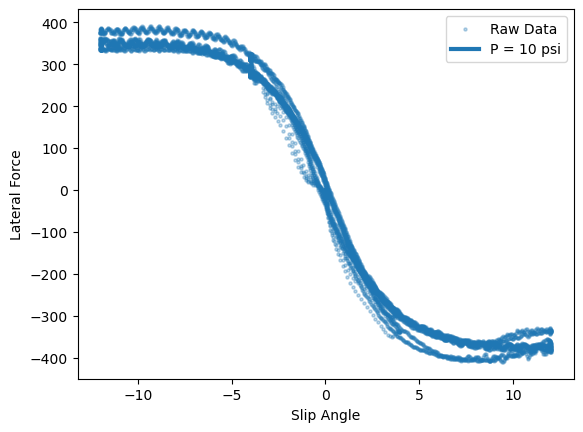

In [34]:
plt.scatter(
    df_slice["SA"],
    df_slice["FY_lb"],
    s=5,
    alpha=0.3,
    label="Raw Data"
)

subset = curve_data[curve_data["P_bin"] == "10 psi"]

plt.plot(
    subset["SA_center"],
    subset["FY_lb"],
    linewidth=3,
    label="P = 10 psi"
)

plt.xlabel("Slip Angle")
plt.ylabel("Lateral Force")
plt.legend()
plt.show()